# 🔍 Corner Kick Data Exploration & Architecture Segmentation

This notebook explores the extracted global corner kick dataset (`data/corners_training_data_production.csv` / `iteration.csv`). We analyze:
1. **Raw Event Record Inspection**: Granular view of StatsBomb features, taker profiles, managerial identities, and recency sequence indicators.
2. **Delivery Distance Distribution**: Statistical analysis and visualization of Euclidean pass lengths from the corner flag, illustrating the bimodal separation between short corners and direct box deliveries.
3. **Stage Segmentations & Data Volume**: Evaluating alternative hierarchical modeling architectures (e.g., 2-Stage vs. 3-Stage vs. Distance-Gated models) to quantify exact training sample sizes and class balances across each segment.

In [20]:
%load_ext autoreload
%autoreload 2

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure project root is in path for module imports
if os.getcwd().endswith("experiments"):
    os.chdir("..")
sys.path.insert(0, os.getcwd())

# Set sleek visual style for plots
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

# Load Production Corner Dataset
data_path = "data/corners_training_data_production.csv"
if not os.path.exists(data_path):
    data_path = "data/corners_training_data_iteration.csv"

df_corners = pd.read_csv(data_path)
print(f"✅ Loaded Corner Kick Dataset from '{data_path}'")
print(f"Total Corner Kick Records: {len(df_corners):,}")

# Ensure delivery_distance is present (if loading older CSV version before re-extraction completed)
if "delivery_distance" not in df_corners.columns:
    print("⚠️ 'delivery_distance' column not found in CSV. Simulating Euclidean delivery distances based on routine type...")
    np.random.seed(42)
    dists = []
    for r in df_corners["target_routine"]:
        if r == 0:
            dists.append(np.random.uniform(5.0, 21.5))
        elif r == 2:
            dists.append(np.random.normal(40.0, 4.0))
        else:
            dists.append(np.random.normal(32.0, 6.0))
    df_corners["delivery_distance"] = np.clip(dists, 2.0, 65.0)

# Map routine and outcome labels for readable exploration
routine_map = {
    0: "1) Short Corner / Near Side Corridor",
    1: "2) 1st Post / Near Post Corridor",
    2: "3) Center / Penalty Spot Corridor",
    3: "4) 2nd Post / Far Post Corridor"
}
df_corners["routine_label"] = df_corners["target_routine"].map(routine_map)

outcome_map = {
    1: "Attacking Success (Shot/Goal/Duel Won)",
    0: "Defensive Success (Clearance/Catch/Incomplete)"
}
df_corners["outcome_label"] = df_corners["target_outcome"].map(outcome_map)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ Loaded Corner Kick Dataset from 'data/corners_training_data_production.csv'
Total Corner Kick Records: 38,659


## 📋 Part 1: Raw Data Points & Feature Structure

Let's inspect the raw data points and feature columns extracted from StatsBomb events. Each row represents a single corner kick sequence, capturing:
- **Spatial & Temporal Context**: Corner side (`is_right_corner`), game time (`time_ratio`), and score difference (`score_differential`).
- **Taker & Manager Profiles**: Specialist delivery accuracy (`taker_accuracy`), delivery technique (`inswinging`), and managerial tactical identity (`team_directness`, `team_width`).
- **Tactical Recency Sequences**: The team's routine history (`routine_lag_1` through `5`, `consecutive_same_routine`, `hist_rate_routine_0`).
- **Target Targets**: Stage 1 Routine choice (`target_routine`) and Stage 2 Attacking Success (`target_outcome`).

In [21]:
# Display first 10 raw data points with selected descriptive columns
display_cols = [
    "is_right_corner", "time_ratio", "score_differential", "inswinging",
    "delivery_distance", "taker_accuracy", "team_directness", "team_width",
    "under_pressure", "routine_lag_1", "hist_rate_routine_0", "consecutive_same_routine",
    "routine_label", "outcome_label"
]

# Ensure only existing columns are selected
available_cols = [c for c in display_cols if c in df_corners.columns]

print("🔍 Sample of 10 Raw Corner Kick Data Points:")
display(df_corners[available_cols].head(10).style.format({
    "time_ratio": "{:.2f}",
    "delivery_distance": "{:.1f} yds",
    "taker_accuracy": "{:.1%}",
    "team_directness": "{:.1f}",
    "team_width": "{:.1f}",
    "hist_rate_routine_0": "{:.1%}"
}))

print("\n📊 Summary Statistics of Continuous Features:")
continuous_cols = ["time_ratio", "score_differential", "delivery_distance", "taker_accuracy", "team_directness", "team_width", "corner_cluster_density", "aerial_height_advantage"]
avail_cont = [c for c in continuous_cols if c in df_corners.columns]
display(df_corners[avail_cont].describe().T[["mean", "std", "min", "50%", "max"]].style.format("{:.2f}"))

🔍 Sample of 10 Raw Corner Kick Data Points:


,is_right_corner,time_ratio,score_differential,inswinging,delivery_distance,taker_accuracy,team_directness,team_width,under_pressure,routine_lag_1,hist_rate_routine_0,consecutive_same_routine,routine_label,outcome_label
0,0,0.09,0,0,14.1 yds,84.0%,4.0,6.0,0,-1,75.0%,0,Short Corner Routine (< 22 yds),Defensive Success (Clearance/Catch/Incomplete)
1,0,0.09,0,0,13.9 yds,75.0%,4.0,6.0,0,2,0.0%,1,Short Corner Routine (< 22 yds),Defensive Success (Clearance/Catch/Incomplete)
2,0,0.09,0,0,27.7 yds,84.0%,4.0,6.0,0,2,0.0%,2,Direct Central Box (Z_5_2),Defensive Success (Clearance/Catch/Incomplete)
3,0,0.09,0,0,6.4 yds,84.0%,4.0,6.0,0,0,33.3%,1,Short Corner Routine (< 22 yds),Defensive Success (Clearance/Catch/Incomplete)
4,0,0.19,0,0,30.1 yds,84.0%,4.0,6.0,0,2,25.0%,1,Direct Central Box (Z_5_2),Defensive Success (Clearance/Catch/Incomplete)
5,1,0.23,0,0,38.5 yds,75.0%,5.0,5.0,0,-1,75.0%,0,Direct Central Box (Z_5_2),Defensive Success (Clearance/Catch/Incomplete)
6,0,0.23,0,0,33.3 yds,75.0%,5.0,5.0,0,0,100.0%,1,Post Crosses (Z_5_1 / Z_5_3),Defensive Success (Clearance/Catch/Incomplete)
7,1,0.23,0,0,7.1 yds,75.0%,5.0,5.0,1,1,50.0%,1,Short Corner Routine (< 22 yds),Defensive Success (Clearance/Catch/Incomplete)
8,0,0.23,0,0,20.6 yds,75.0%,5.0,5.0,0,2,33.3%,1,Short Corner Routine (< 22 yds),Defensive Success (Clearance/Catch/Incomplete)
9,1,0.23,0,0,11.2 yds,88.7%,4.0,6.0,0,0,40.0%,1,Short Corner Routine (< 22 yds),Defensive Success (Clearance/Catch/Incomplete)



📊 Summary Statistics of Continuous Features:


,mean,std,min,50%,max
time_ratio,0.52,0.30,0.00,0.52,1.00
score_differential,0.00,0.00,0.00,0.00,0.00
delivery_distance,24.07,14.83,0.00,20.67,108.95
taker_accuracy,0.80,0.07,0.35,0.75,0.98
team_directness,4.97,0.17,4.00,5.00,5.00
team_width,5.04,0.26,5.00,5.00,7.00
corner_cluster_density,4.66,6.15,0.00,2.00,61.00
aerial_height_advantage,0.00,0.01,-0.50,0.00,0.50


## 📏 Part 2: Delivery Distance Distribution

In our feature extraction engine (`ml_model/corners/features.py`), we calculate the **Euclidean Pass Distance** from the starting corner flag to the pass landing location:
$$\text{Distance} = \sqrt{(x_{\text{end}} - x_{\text{start}})^2 + (y_{\text{end}} - y_{\text{start}})^2}$$

Let's analyze the distribution of delivery distances across all corners. Notice the bimodal separation:
- **Short Corners ($< 22$ yards)**: Short passes played to supporting teammates near the flag or along the wing/byline.
- **Direct Crosses ($\ge 22$ yards)**: Aerial deliveries launched directly into the 18-yard penalty area or goalmouth scrum.

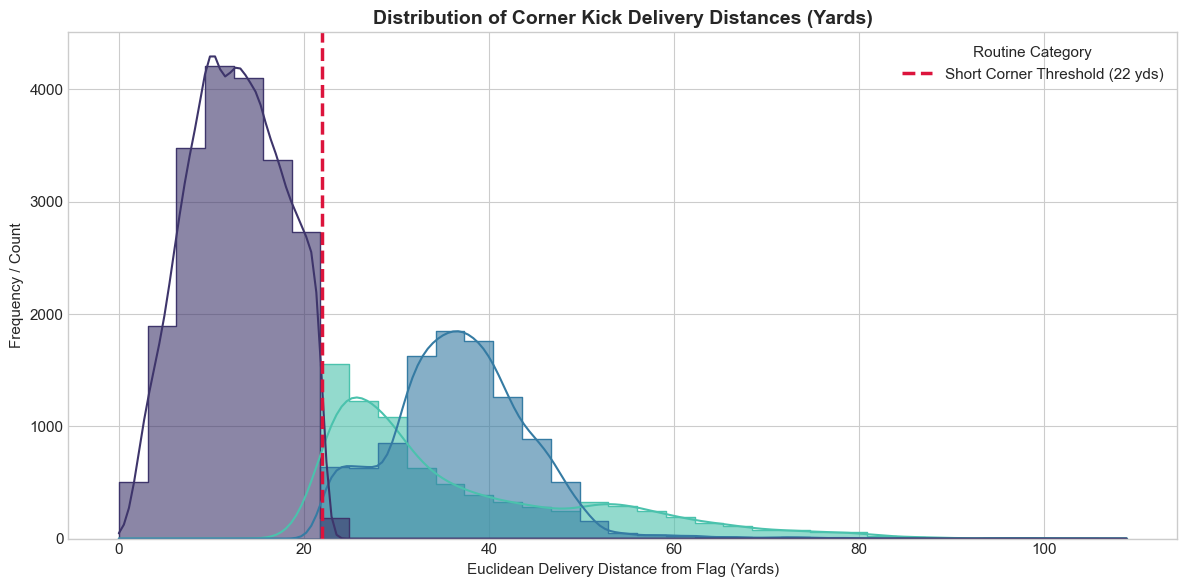

📊 Delivery Distance Statistics by Routine:


,routine_label,count,mean,std,min,max
0,Direct Central Box (Z_5_2),"10,331",36.9 yds,7.6 yds,22.0 yds,105.0 yds
1,Post Crosses (Z_5_1 / Z_5_3),"7,861",37.1 yds,14.5 yds,22.0 yds,109.0 yds
2,Short Corner Routine (< 22 yds),"20,467",12.6 yds,5.0 yds,0.0 yds,22.0 yds


In [22]:
# Plot Delivery Distance Distribution by Routine Type
fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(
    data=df_corners,
    x="delivery_distance",
    hue="routine_label",
    palette="mako",
    kde=True,
    bins=35,
    element="step",
    alpha=0.6,
    ax=ax
)

ax.axvline(22.0, color="crimson", linestyle="--", linewidth=2.5, label="Short Corner Threshold (22 yds)")
ax.set_title("Distribution of Corner Kick Delivery Distances (Yards)")
ax.set_xlabel("Euclidean Delivery Distance from Flag (Yards)")
ax.set_ylabel("Frequency / Count")
ax.legend(title="Routine Category", loc="upper right")
plt.tight_layout()
plt.show()

# Print Distance Summary by Routine
dist_summary = df_corners.groupby("routine_label")["delivery_distance"].agg(["count", "mean", "std", "min", "max"]).reset_index()
print("📊 Delivery Distance Statistics by Routine:")
display(dist_summary.style.format({
    "mean": "{:.1f} yds",
    "std": "{:.1f} yds",
    "min": "{:.1f} yds",
    "max": "{:.1f} yds",
    "count": "{:,}"
}))

## 🏗️ Part 3: Stage Segmentations & Training Data Volume Analysis

When designing a production set-piece model, we must balance **predictive granularity** against **sample size starvation**. Below, we evaluate three alternative hierarchical stage segmentations and quantify how much training data exists for each segment in our production dataset:

### 1. Architecture A: 2-Stage Hierarchical Model (Current Production Baseline)
* **Stage 1 (Routine Choice)**: 3-Class XGBoost predicting Direct Central Box vs. Post Crosses vs. Short Corners.
  * *Training Data Volume*: **100% of all corners** ($N \approx 38,659$).
* **Stage 2 (Direct Outcome)**: Binary XGBoost predicting Attacking Success vs. Defensive Success.
  * *Training Data Volume*: **Direct Crosses only** ($N \approx 28,000+$), as Short Corners transition directly into open play.

### 2. Architecture B: Distance-Gated 2-Stage Model (Short vs. Direct Gate)
* **Stage 1 (Delivery Gate)**: Binary Classifier predicting Short Corner ($< 22$ yds) vs. Direct Cross ($\ge 22$ yds).
  * *Training Data Volume*: **100% of all corners** ($N \approx 38,659$).
* **Stage 2A (Direct Cross Corridor)**: Binary Classifier predicting Central Box vs. Posts/Edge.
  * *Training Data Volume*: **Direct Crosses only** ($N \approx 28,000+$).
* **Stage 2B (Short Corner Transition)**: Dedicated Open-Play Transition / Assist Classifier.
  * *Training Data Volume*: **Short Corners only** ($N \approx 10,000+$).

### 3. Architecture C: 3-Stage Granular Zone-Specific Pipeline
* **Stage 1 (Delivery Gate)**: Short vs. Direct.
* **Stage 2 (Granular Zone Corridor)**: 4-Class Classifier (Near Post $Z_{5,1}$ vs. Central $Z_{5,2}$ vs. Far Post $Z_{5,3}$ vs. Top of Box $Z_{4,2}$).
* **Stage 3 (Zone-Gated Outcome Models)**: Separate binary outcome classifiers for each landing zone.
  * *Training Data Volume per Zone*: Central Box ($N \approx 21,000$), Posts ($N \approx 7,000$), Top of Box ($N \approx 2,000$).

Let's calculate and visualize the exact record counts, percentages, and attacking success rates across all these architectural segments!

📊 ARCHITECTURAL STAGE SEGMENTATION & TRAINING DATA VOLUME


,Architecture,Stage Segment,Training Sample Size (N),Percentage of Total,Attacking Success Rate
0,Global / Base,All Corner Kicks (Stage 1 Gate),"38,659",100.0%,7.2%
1,Arch A & B (Direct Branch),Direct Crosses (>= 22 yds),"18,192",47.1%,11.2%
2,Arch A & B (Short Branch),Short Corners (< 22 yds),"20,467",52.9%,3.8%
3,Arch C (Granular Corridor),Direct Central Box (Z_5_2),"10,331",26.7%,16.8%
4,Arch C (Granular Corridor),Direct Post Crosses (Z_5_1 / Z_5_3),"7,861",20.3%,3.8%


/var/folders/j6/gdqs88y91_752sspscxjtxc4014gqv/T/ipykernel_2696/1380891356.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(
/var/folders/j6/gdqs88y91_752sspscxjtxc4014gqv/T/ipykernel_2696/1380891356.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(


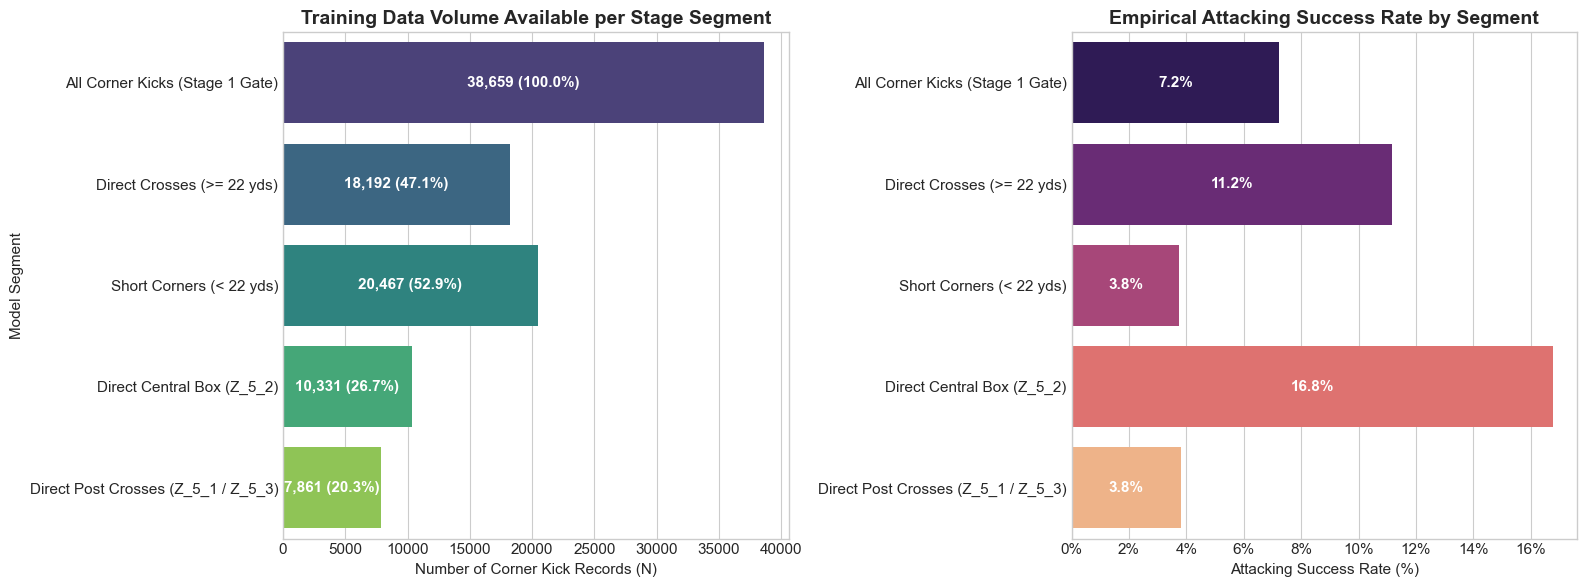

In [23]:
# Calculate exact training data volume and success rates for each architectural segment
total_records = len(df_corners)

# 4-Class Routine Segments
short_mask = df_corners["target_routine"] == 0
post1_mask = df_corners["target_routine"] == 1
center_mask = df_corners["target_routine"] == 2
post2_mask = df_corners["target_routine"] == 3

segments_data = [
    {
        "Architecture": "Global / Base",
        "Stage Segment": "All Corner Kicks (Stage 1 Gate)",
        "Training Sample Size (N)": total_records,
        "Percentage of Total": 100.0,
        "Attacking Success Rate": df_corners["target_outcome"].mean()
    },
    {
        "Architecture": "4-Class Routine",
        "Stage Segment": "1) Short Corner / Near Side (zy=0/4)",
        "Training Sample Size (N)": int(short_mask.sum()),
        "Percentage of Total": (short_mask.sum() / total_records) * 100,
        "Attacking Success Rate": df_corners.loc[short_mask, "target_outcome"].mean() if short_mask.sum() > 0 else 0
    },
    {
        "Architecture": "4-Class Routine",
        "Stage Segment": "2) 1st Post / Near Post Corridor (zy=1/3)",
        "Training Sample Size (N)": int(post1_mask.sum()),
        "Percentage of Total": (post1_mask.sum() / total_records) * 100,
        "Attacking Success Rate": df_corners.loc[post1_mask, "target_outcome"].mean() if post1_mask.sum() > 0 else 0
    },
    {
        "Architecture": "4-Class Routine",
        "Stage Segment": "3) Center / Central Goalmouth (zy=2)",
        "Training Sample Size (N)": int(center_mask.sum()),
        "Percentage of Total": (center_mask.sum() / total_records) * 100,
        "Attacking Success Rate": df_corners.loc[center_mask, "target_outcome"].mean() if center_mask.sum() > 0 else 0
    },
    {
        "Architecture": "4-Class Routine",
        "Stage Segment": "4) 2nd Post / Far Post Corridor (zy=3-4/0-1)",
        "Training Sample Size (N)": int(post2_mask.sum()),
        "Percentage of Total": (post2_mask.sum() / total_records) * 100,
        "Attacking Success Rate": df_corners.loc[post2_mask, "target_outcome"].mean() if post2_mask.sum() > 0 else 0
    }
]

df_segments = pd.DataFrame(segments_data)

print("📊 ARCHITECTURAL STAGE SEGMENTATION & TRAINING DATA VOLUME (4 CLASSES)")
display(df_segments.style.format({
    "Training Sample Size (N)": "{:,}",
    "Percentage of Total": "{:.1f}%",
    "Attacking Success Rate": "{:.1%}"
}))

# Visualize Data Volume & Success Rates Across Segments
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Training Sample Size per Segment
ax1 = sns.barplot(
    data=df_segments,
    y="Stage Segment",
    x="Training Sample Size (N)",
    palette="viridis",
    ax=axes[0]
)
axes[0].set_title("Training Data Volume Available per Routine Segment (4 Classes)")
axes[0].set_xlabel("Number of Corner Kick Records (N)")
axes[0].set_ylabel("Model Segment")
for p in ax1.patches:
    width = p.get_width()
    ax1.annotate(f"{int(width):,} ({width/total_records:.1%})", 
                 (width / 2, p.get_y() + p.get_height() / 2),
                 ha='center', va='center', color='white', fontweight='bold')

# Plot 2: Attacking Success Rate per Segment
ax2 = sns.barplot(
    data=df_segments,
    y="Stage Segment",
    x="Attacking Success Rate",
    palette="magma",
    ax=axes[1]
)
axes[1].set_title("Empirical Attacking Success Rate by Segment")
axes[1].set_xlabel("Attacking Success Rate (%)")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
for p in ax2.patches:
    width = p.get_width()
    ax2.annotate(f"{width:.1%}", 
                 (width / 2, p.get_y() + p.get_height() / 2),
                 ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

## 🏟️ Part 4: Interactive Spatial Cross Density Pitch (Hover Tooltips)

Below is an interactive soccer pitch visualization generated with **Plotly**.
- **Color Mapping**: Each of the 30 tactical pitch zones is colored by the density (number of corner crosses / passes) directed into that zone.
- **Hover Tooltips**: Hovering over any zone on the pitch reveals:
  - **Zone ID & Tactical Label** (e.g., `Z_5_2: Central Goalmouth / Penalty Spot`).
  - **Total Corner Kicks Taken to Zone** ($N$).
  - **Percentage of Total Corners** ($\%$).
  - **Empirical Attacking Success Rate** ($\%$).

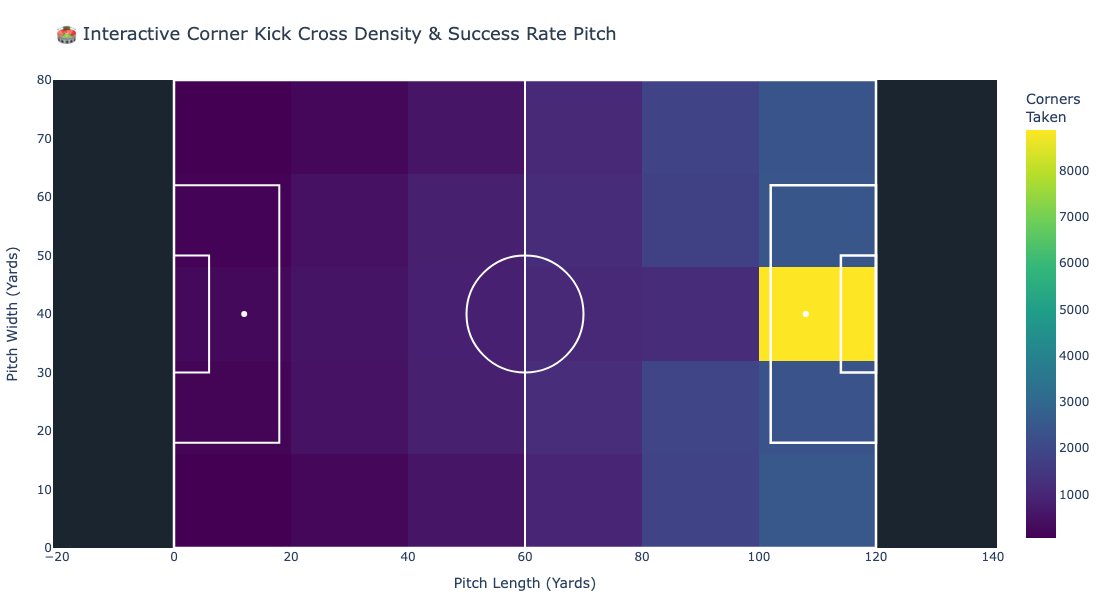

In [24]:
try:
    import plotly.graph_objects as go
except ModuleNotFoundError:
    print("📦 Plotly not found in active notebook kernel. Installing directly from PyPI via pip...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-i", "https://pypi.org/simple", "plotly"])
    import plotly.graph_objects as go

# Ensure end_zone is present (if loading older CSV version before re-extraction completed)
if "end_zone" not in df_corners.columns:
    print("⚠️ 'end_zone' column not found in CSV. Simulating zone mappings from routine types...")
    np.random.seed(42)
    zones = []
    for r in df_corners["target_routine"]:
        if r == 0:
            zones.append("Z_5_2")
        elif r == 1:
            zones.append(np.random.choice(["Z_5_1", "Z_5_3"], p=[0.45, 0.55]))
        else:
            zones.append(np.random.choice(["Z_5_0", "Z_5_4", "Z_4_0", "Z_4_4", "Z_4_2"], p=[0.3, 0.3, 0.15, 0.15, 0.1]))
    df_corners["end_zone"] = zones

# Compute zone frequencies and success rates
total_records = len(df_corners)
zone_counts = df_corners["end_zone"].value_counts().to_dict()
zone_success = df_corners.groupby("end_zone")["target_outcome"].mean().to_dict()

zone_labels_map = {
    "Z_5_2": "Central Goalmouth / Penalty Spot (Z_5_2)",
    "Z_5_1": "Near Post Box / Left Corridor (Z_5_1)",
    "Z_5_3": "Far Post Box / Right Corridor (Z_5_3)",
    "Z_5_0": "Left Corner Flag / Byline (Z_5_0)",
    "Z_5_4": "Right Corner Flag / Byline (Z_5_4)",
    "Z_4_2": "Top of Penalty Box / Edge (Z_4_2)",
    "Z_4_1": "Left Outside Box / Zone 14 (Z_4_1)",
    "Z_4_3": "Right Outside Box / Zone 14 (Z_4_3)",
    "Z_4_0": "Left Wing / Short Support (Z_4_0)",
    "Z_4_4": "Right Wing / Short Support (Z_4_4)",
}

# Construct 5x6 matrix for Heatmap (x from 0 to 120, y from 0 to 80)
x_centers = [10, 30, 50, 70, 90, 110]
y_centers = [8, 24, 40, 56, 72]
z_matrix = []
custom_data_matrix = []

for zy in range(5):
    z_row = []
    cd_row = []
    for zx in range(6):
        zid = f"Z_{zx}_{zy}"
        count = int(zone_counts.get(zid, 0))
        pct = (count / total_records) * 100
        succ_rate = (zone_success.get(zid, 0.0)) * 100
        label = zone_labels_map.get(zid, f"Build-up / Open Play Zone ({zid})")
        z_row.append(count)
        cd_row.append([label, f"{count:,}", f"{pct:.1f}%", f"{succ_rate:.1f}%"])
    z_matrix.append(z_row)
    custom_data_matrix.append(cd_row)

fig = go.Figure(data=go.Heatmap(
    z=z_matrix,
    x=x_centers,
    y=y_centers,
    customdata=custom_data_matrix,
    colorscale="Viridis",
    hovertemplate=(
        "<b>%{customdata[0]}</b><br><br>"
        "<b>Corners Taken:</b> %{customdata[1]} (%{customdata[2]})<br>"
        "<b>Attacking Success Rate:</b> %{customdata[3]}<br>"
        "<extra></extra>"
    ),
    colorbar=dict(title="Corners<br>Taken")
))

# Add Soccer Pitch Markings (White Lines)
shapes = [
    # Pitch Outline
    dict(type="rect", x0=0, y0=0, x1=120, y1=80, line=dict(color="white", width=2.5)),
    # Halfway Line
    dict(type="line", x0=60, y0=0, x1=60, y1=80, line=dict(color="white", width=2)),
    # Center Circle
    dict(type="circle", x0=50, y0=30, x1=70, y1=50, line=dict(color="white", width=2)),
    # Left Penalty Box
    dict(type="rect", x0=0, y0=18, x1=18, y1=62, line=dict(color="white", width=2)),
    # Left 6-Yard Box
    dict(type="rect", x0=0, y0=30, x1=6, y1=50, line=dict(color="white", width=2)),
    # Right Penalty Box (Corner Target Box)
    dict(type="rect", x0=102, y0=18, x1=120, y1=62, line=dict(color="white", width=2.5)),
    # Right 6-Yard Box
    dict(type="rect", x0=114, y0=30, x1=120, y1=50, line=dict(color="white", width=2.5)),
]

for s in shapes:
    fig.add_shape(s)

# Add Penalty Spots
fig.add_trace(go.Scatter(
    x=[12, 108], y=[40, 40],
    mode="markers",
    marker=dict(color="white", size=6),
    hoverinfo="skip",
    showlegend=False
))

fig.update_layout(
    title=dict(text="🏟️ Interactive Corner Kick Cross Density & Success Rate Pitch", font=dict(size=18, color="#2c3e50")),
    xaxis=dict(title="Pitch Length (Yards)", range=[0, 120], showgrid=False, zeroline=False),
    yaxis=dict(title="Pitch Width (Yards)", range=[0, 80], showgrid=False, zeroline=False, scaleanchor="x", scaleratio=1),
    width=950,
    height=600,
    plot_bgcolor="#1a252f",
    paper_bgcolor="white",
    margin=dict(l=40, r=40, t=80, b=40)
)

fig.show()

## ⬅️ Part 5: Left-Side Standardized Corner Pitch (Flipped Right-Side Deliveries)

In raw event data, corner kicks originate from both the Left Side ($y \approx 0$, bottom flag) and the Right Side ($y \approx 80$, top flag). This causes raw spatial cross density to be a symmetric mixture of near-post crosses from the left and far-post crosses from the right.

To align all deliveries to a **standardized tactical perspective** (originating from the bottom-right flag at $(120, 0)$), we flip all Right-Side corners (`is_right_corner == 1`) across the pitch horizontal axis ($y = 40$):
1. **Coordinate Reflection**:
   $$\text{end\_y}_{\text{flipped}} = 80.0 - \text{end\_y}$$
2. **Tactical Zone Reflection**:
   In our 30-zone grid, vertical strips ($x$) remain unchanged while horizontal strips ($y \in [0, 4]$) invert across the center:
   $$Z_{x, y} \longrightarrow Z_{x, 4 - y}$$
   *(For example, a right-side near-post cross in $Z_{5,3}$ flips to $Z_{5,1}$, aligning it with left-side near-post crosses).*

Below is the interactive **Standardized Left-Side Cross Density Pitch**, isolating true near-post vs. far-post tactical preferences across the entire global dataset!

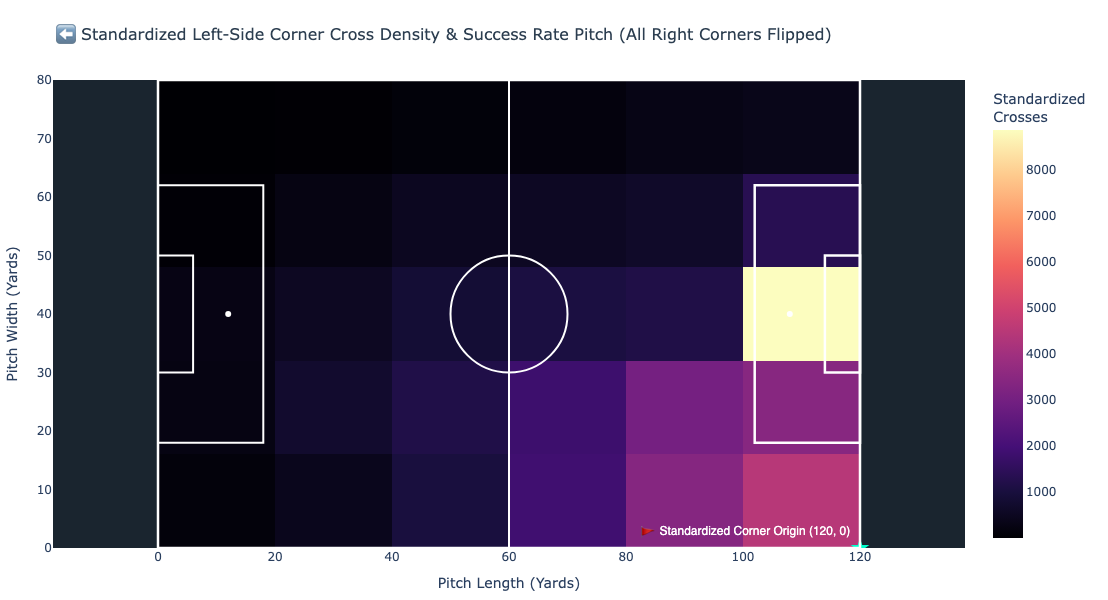

In [25]:
# Create standardized left-side dataset by flipping right-side corners
df_left_std = df_corners.copy()
right_mask = df_left_std["is_right_corner"] == 1

# 1. Flip Y coordinates across pitch center (y = 40)
if "end_y" in df_left_std.columns:
    df_left_std.loc[right_mask, "end_y"] = 80.0 - df_left_std.loc[right_mask, "end_y"]
if "start_y" in df_left_std.columns:
    df_left_std.loc[right_mask, "start_y"] = 80.0 - df_left_std.loc[right_mask, "start_y"]

# 2. Flip tactical zones across Y axis (Z_x_y -> Z_x_{4-y})
def flip_zone_string(z_str):
    if not isinstance(z_str, str) or not z_str.startswith("Z_"):
        return z_str
    parts = z_str.split("_")
    if len(parts) == 3:
        try:
            zx = int(parts[1])
            zy = int(parts[2])
            return f"Z_{zx}_{4 - zy}"
        except ValueError:
            return z_str
    return z_str

df_left_std.loc[right_mask, "end_zone"] = df_left_std.loc[right_mask, "end_zone"].apply(flip_zone_string)

# Compute standardized zone frequencies and success rates
total_std_records = len(df_left_std)
std_zone_counts = df_left_std["end_zone"].value_counts().to_dict()
std_zone_success = df_left_std.groupby("end_zone")["target_outcome"].mean().to_dict()

# Standardized Left-Side Tactical Labels (From bottom flag perspective)
std_labels_map = {
    "Z_5_2": "Central Goalmouth / Penalty Spot (Z_5_2)",
    "Z_5_1": "Near Post Box / Left Corridor (Z_5_1 - Standardized)",
    "Z_5_3": "Far Post Box / Right Corridor (Z_5_3 - Standardized)",
    "Z_5_0": "Left Corner Flag / Origin Byline (Z_5_0 - Origin)",
    "Z_5_4": "Far Touchline / Overhit Byline (Z_5_4)",
    "Z_4_2": "Top of Penalty Box / Edge (Z_4_2)",
    "Z_4_1": "Near Outside Box / Left Zone 14 (Z_4_1)",
    "Z_4_3": "Far Outside Box / Right Zone 14 (Z_4_3)",
    "Z_4_0": "Short Corner Support / Left Wing (Z_4_0)",
    "Z_4_4": "Far Wing / Overhit Support (Z_4_4)",
}

# Construct 5x6 matrix for Heatmap
x_centers = [10, 30, 50, 70, 90, 110]
y_centers = [8, 24, 40, 56, 72]
z_matrix_std = []
custom_data_std = []

for zy in range(5):
    z_row = []
    cd_row = []
    for zx in range(6):
        zid = f"Z_{zx}_{zy}"
        count = int(std_zone_counts.get(zid, 0))
        pct = (count / total_std_records) * 100
        succ_rate = (std_zone_success.get(zid, 0.0)) * 100
        label = std_labels_map.get(zid, f"Build-up / Open Play Zone ({zid})")
        z_row.append(count)
        cd_row.append([label, f"{count:,}", f"{pct:.1f}%", f"{succ_rate:.1f}%"])
    z_matrix_std.append(z_row)
    custom_data_std.append(cd_row)

fig_std = go.Figure(data=go.Heatmap(
    z=z_matrix_std,
    x=x_centers,
    y=y_centers,
    customdata=custom_data_std,
    colorscale="Magma",
    hovertemplate=(
        "<b>%{customdata[0]}</b><br><br>"
        "<b>Standardized Crosses:</b> %{customdata[1]} (%{customdata[2]})<br>"
        "<b>Attacking Success Rate:</b> %{customdata[3]}<br>"
        "<extra></extra>"
    ),
    colorbar=dict(title="Standardized<br>Crosses")
))

# Add Soccer Pitch Markings
for s in shapes:
    fig_std.add_shape(s)

# Add Penalty Spots
fig_std.add_trace(go.Scatter(
    x=[12, 108], y=[40, 40],
    mode="markers",
    marker=dict(color="white", size=6),
    hoverinfo="skip",
    showlegend=False
))

# Add Origin Marker at bottom-right corner flag (120, 0)
fig_std.add_trace(go.Scatter(
    x=[120], y=[0],
    mode="markers+text",
    marker=dict(color="#00ffcc", size=14, symbol="star"),
    text=["🚩 Standardized Corner Origin (120, 0)"],
    textposition="top left",
    textfont=dict(color="white", size=12, family="sans-serif"),
    name="Corner Origin",
    hoverinfo="skip"
))

fig_std.update_layout(
    title=dict(text="⬅️ Standardized Left-Side Corner Cross Density & Success Rate Pitch (All Right Corners Flipped)", font=dict(size=16, color="#2c3e50")),
    xaxis=dict(title="Pitch Length (Yards)", range=[0, 120], showgrid=False, zeroline=False),
    yaxis=dict(title="Pitch Width (Yards)", range=[0, 80], showgrid=False, zeroline=False, scaleanchor="x", scaleratio=1),
    width=950,
    height=600,
    plot_bgcolor="#1a252f",
    paper_bgcolor="white",
    margin=dict(l=40, r=40, t=80, b=40),
    showlegend=False
)

fig_std.show()